# Speaker-level sentiment in Bangla financial talk shows
### Fine-tuning BanglaBERT on LLM-judged speaker scripts

This notebook fine-tunes a Bangla transformer to predict **the evaluative stance a speaker
takes on the economy**, in a corpus of 25 Bangla financial television episodes that were
transcribed with Whisper-family ASR and diarized with pyannote.

**Where the labels come from.** No human labels exist anywhere in this project: all 3,023
annotation drafts in the original bundles carry `labels: []` and
`annotation_status: "review_required"`. Supervision is created by an LLM judge
(`speaker_sentiment/llm_judge.py`) that reads each speaker's *entire* script in one call and
returns both a holistic speaker verdict and a label for every turn. Those turn labels are what
this notebook trains on; the speaker verdict is what it is ultimately evaluated against.

**The two tasks.**

| | unit | classes | n | role |
|---|---|---|---|---|
| Task A | speaker **turn** | negative / neutral / positive | **1,340** (886 train / 244 val / 210 test) | what BERT is trained on |
| Task B | **speaker** in an episode | negative / mixed / neutral / positive | **61** of 72 judged units | what we actually want |

1,545 turns were judged; 205 came back `illegible` and are dropped, leaving 1,340 supervised rows.

A turn's stance does not depend on knowing who said it, so `llm_judge.py --scope all` also labels
the fallback-diarized episodes and the unassigned buckets: +69% training data for Task A, kept
out of Task B by the `speaker_level_valid` flag.

Task B has too few examples to fine-tune a 110M-parameter encoder directly. The design is
therefore hierarchical: train on Task A, then aggregate predicted turn stance into a speaker
verdict and score that against the judge. Section 9 also trains a genuinely hierarchical model
(turn encoder + attention pooling over a speaker's turns) for comparison.

**Run order.** Sections 1-8 are the main path. Section 9 (hierarchical) and Section 10
(backbone sweep) are optional extensions.

**Runtime, measured on this corpus** (886 train turns, batch 16, 6 epochs):

| | main path, sections 1-8 |
|---|---|
| Colab T4 GPU, `max_len=256` | **~3 min** |
| CPU (10 threads), `max_len=256` | ~60 min |
| CPU (10 threads), `max_len=128` | ~30 min |

A GPU is **not** required for one training run. It becomes necessary for section 10's eight-config
ablation (~8 h on CPU) and for seed-averaging. On CPU, set `CFG.max_len = 128` below.

**Running this on Colab.** Section 1 detects Colab, mounts Drive and finds the data by itself.
The one thing you do by hand is put the folder on Drive:

1. Zip `speaker_sentiment/` on your machine and upload it to **My Drive** (drag it into
   [drive.google.com](https://drive.google.com), then right-click → *Extract* — or upload the
   folder directly). You need at least the `data/` subfolder and this notebook.
2. In Colab: **Runtime → Change runtime type → T4 GPU**.
3. Run section 1. It mounts Drive, searches for the corpus, and prints which paths it found.
   If it cannot find the folder, it tells you exactly what to set `DRIVE_PROJECT` to.

Nothing else in the notebook contains a path. `max_len` is chosen from the device
(256 on GPU, 128 on CPU) unless you override it.

**Prerequisites** — these produce `data/`, and are **already done**; re-run only if you change
the corpus or the judging:

```bash
python speaker_sentiment/build_speaker_corpus.py --data-root "D:/ML DATASETS"
export ANTHROPIC_API_KEY=...
python speaker_sentiment/llm_judge.py --scope all --passes 3   # optional: see README section 3
python speaker_sentiment/make_datasets.py
```


## 1. Environment


In [1]:
# Dependencies. On Colab, torch/transformers are usually present already - this only
# fills the gaps. The csebuetnlp normalizer is NOT optional: BanglaBERT was pretrained on
# text put through it, and skipping it costs a couple of F1 points on its own.
import importlib, subprocess, sys

def ensure(module, spec):
    try:
        importlib.import_module(module)
        return False
    except ImportError:
        print(f"installing {spec} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", spec], check=False)
        return True

installed = [
    ensure("transformers", "transformers>=4.40"),
    ensure("torch", "torch"),
    ensure("sklearn", "scikit-learn"),
    ensure("pandas", "pandas"),
    ensure("matplotlib", "matplotlib"),
    ensure("normalizer", "git+https://github.com/csebuetnlp/normalizer"),
]
print("all dependencies present" if not any(installed)
      else "installed the missing ones - restart the runtime only if an import below fails")


installing git+https://github.com/csebuetnlp/normalizer ...
installed the missing ones - restart the runtime only if an import below fails


### Where the data lives

This cell is the only place in the notebook that knows about paths. It works in three
situations without being edited:

| you are on | what happens |
|---|---|
| **Colab + Drive** | mounts Drive and searches `My Drive` for a folder holding `data/turns_train.jsonl` |
| **Colab, no Drive** | falls back to whatever you uploaded into `/content` |
| **your own machine** | walks up from the working directory looking for `speaker_sentiment/data` |

If it guesses wrong, set `DRIVE_PROJECT` by hand at the top and re-run — that is the single
override, and everything downstream follows it.


In [2]:
from pathlib import Path
import os, sys, json

# ---- override here only if the search below picks the wrong folder ----------
DRIVE_PROJECT = None          # e.g. Path("/content/drive/MyDrive/speaker_sentiment")
# -----------------------------------------------------------------------------

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
REQUIRED = [f"{kind}_{split}.jsonl"
            for kind in ("turns", "speakers")
            for split in ("train", "val", "test")]
SKIP_DIRS = {".git", "__pycache__", ".ipynb_checkpoints", "node_modules", ".venv",
             "runs", "processed", "asr", "diarization", "fused", "drafts",
             "annotated", "aggregated", "artifacts", "models", "raw",
             ".shortcut-targets-by-id", ".Trash", "Colab Notebooks"}

def data_dir_of(folder: Path):
    """Return the folder holding the six split files, or None."""
    for cand in (folder / "data", folder):
        try:
            if all((cand / f).exists() for f in REQUIRED):
                return cand
        except OSError:
            pass
    return None

def find_all(roots, max_depth=6):
    """Every folder in Drive that holds a complete corpus. Breadth-first, shallow first."""
    hits, seen = [], set()
    frontier = [(Path(r), 0) for r in roots if Path(r).exists()]
    while frontier:
        here, depth = frontier.pop(0)
        rp = str(here)
        if rp in seen:
            continue
        seen.add(rp)
        d = data_dir_of(here)
        if d is not None:
            hits.append((here, d))
            continue                      # do not descend into a matched project
        if depth >= max_depth:
            continue
        try:
            kids = sorted(p for p in here.iterdir() if p.is_dir())
        except (PermissionError, OSError):
            continue
        for k in kids:
            if k.name in SKIP_DIRS or k.name.startswith("."):
                continue
            frontier.append((k, depth + 1))
    return hits

if IN_COLAB and DRIVE_PROJECT is None:
    try:
        from google.colab import drive
        if not os.path.ismount("/content/drive"):
            drive.mount("/content/drive")
        print("Drive mounted at /content/drive")
    except Exception as exc:
        print(f"could not mount Drive ({exc}); looking in /content instead")

if DRIVE_PROJECT is not None:
    PROJECT_DIR = Path(DRIVE_PROJECT)
    DATA_DIR = data_dir_of(PROJECT_DIR) or (PROJECT_DIR / "data")
    candidates = [(PROJECT_DIR, DATA_DIR)]
else:
    roots = (["/content/drive/MyDrive", "/content/drive/Shareddrives", "/content"]
             if IN_COLAB else [Path.cwd(), *Path.cwd().parents][:4])
    candidates = find_all(roots)
    if not candidates:
        raise FileNotFoundError(
            "Could not find the corpus anywhere in Drive.\n"
            "Expected a folder whose data/ contains:\n  " + "\n  ".join(REQUIRED) +
            "\n\nUpload the speaker_sentiment folder to My Drive (or unzip it there),"
            "\nthen re-run this cell. If it is somewhere unusual, set DRIVE_PROJECT"
            '\nat the top of this cell, e.g. Path("/content/drive/MyDrive/speaker_sentiment").')

    def n_turns(data_dir):
        try:
            with (data_dir / "turns_train.jsonl").open(encoding="utf-8") as fh:
                return sum(1 for _ in fh)
        except OSError:
            return -1

    scored = sorted(candidates,
                    key=lambda c: (c[1] / "turns_train.jsonl").stat().st_mtime,
                    reverse=True)
    if len(scored) > 1:
        print(f"found {len(scored)} corpus folders in Drive - using the most recent:")
        for folder, d in scored:
            print(f"   {'->' if (folder, d) == scored[0] else '  '} {folder}"
                  f"   ({n_turns(d)} training turns)")
        print("   (delete the stale copies, or set DRIVE_PROJECT, to remove the ambiguity)")
    PROJECT_DIR, DATA_DIR = scored[0]

OUT_DIR = PROJECT_DIR / "runs" / "banglabert_turn"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"project : {PROJECT_DIR}")
print(f"data    : {DATA_DIR}")
print(f"output  : {OUT_DIR}")

missing = [f for f in REQUIRED if not (DATA_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f"MISSING split files: {missing}")
print("all six split files present")

# ---- is this the corpus we think it is? -------------------------------------
with (DATA_DIR / "turns_train.jsonl").open(encoding="utf-8") as fh:
    _n_train = sum(1 for _ in fh)
with (DATA_DIR / "speakers_labelled.jsonl").open(encoding="utf-8") as fh:
    _n_spk = sum(1 for _ in fh)
print(f"corpus  : {_n_train} training turns, {_n_spk} judged speaker units")
if _n_train < 1000:
    print("\n*** WARNING: this looks like the FIRST build (886 training turns, 72 units).")
    print("*** The current corpus has 1,009 training turns and 147 judged units.")
    print("*** Delete the old folder from Drive and re-upload, or results will be stale.")
else:
    print("        -> second build (45 episodes) confirmed")


Mounted at /content/drive
Drive mounted at /content/drive
project : /content/drive/MyDrive/speaker_sentiment
data    : /content/drive/MyDrive/speaker_sentiment/data
output  : /content/drive/MyDrive/speaker_sentiment/runs/banglabert_turn
all six split files present
corpus  : 1009 training turns, 147 judged speaker units
        -> second build (45 episodes) confirmed


In [3]:
import json, math, random, re, os, time, warnings
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             accuracy_score, cohen_kappa_score)

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))
elif IN_COLAB:
    print("No GPU on this Colab runtime. Runtime -> Change runtime type -> T4 GPU, then")
    print("re-run from the top. It will still work on CPU, at ~30 min for sections 1-8.")
else:
    print("No GPU. Sections 1-8 still run in ~30 min (max_len drops to 128 automatically).")
    print("Skip section 10 on CPU - eight configs is roughly 8 hours.")


torch 2.11.0+cu128 | device: cuda
Tesla T4


In [4]:
class CFG:
    # --- data ---------------------------------------------------------------
    data_dir      = DATA_DIR     # resolved in the cell above - do not hard-code a path here
    # 256 covers p90 of turn length (see section 4) and is what a GPU should use.
    # On CPU 128 halves the run to ~30 min and truncates 23% of turns instead of ~10%.
    max_len       = 256 if DEVICE.type == "cuda" else 128
    input_mode    = "role_turn"  # plain | role_turn | context | role_context

    # --- model --------------------------------------------------------------
    model_name    = "csebuetnlp/banglabert"
    dropout       = 0.1

    # --- optimisation -------------------------------------------------------
    epochs        = 6
    batch_size    = 16
    lr            = 2e-5
    head_lr       = 1e-4         # classifier head learns faster than the encoder
    weight_decay  = 0.01
    warmup_ratio  = 0.1
    max_grad_norm = 1.0

    # --- noisy-label handling (the labels are LLM-generated, not human) ------
    class_weighting   = True     # counter the neutral majority
    label_smoothing   = 0.1      # do not let the model be certain about silver labels
    use_sample_weights = True    # judge confidence x multi-pass agreement
    freeze_epochs     = 0        # >0 trains the head alone for N epochs first

    seed          = 42
    out_dir       = OUT_DIR      # on Colab this is on Drive, so it survives a disconnect

TURN_CLASSES    = ["negative", "neutral", "positive"]
SPEAKER_CLASSES = ["negative", "mixed", "neutral", "positive"]
T2I = {c: i for i, c in enumerate(TURN_CLASSES)}
I2T = {i: c for c, i in T2I.items()}

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

set_seed(CFG.seed)
CFG.out_dir.mkdir(parents=True, exist_ok=True)
print(f"{CFG.model_name}  |  input_mode={CFG.input_mode}  |  max_len={CFG.max_len}"
      f"  |  epochs={CFG.epochs}  |  device={DEVICE}")
print(f"saving to {CFG.out_dir}")


csebuetnlp/banglabert  |  input_mode=role_turn  |  max_len=256  |  epochs=6  |  device=cuda
saving to /content/drive/MyDrive/speaker_sentiment/runs/banglabert_turn


## 2. Load the judged corpus


In [5]:
def load_jsonl(path):
    with open(path, encoding="utf-8") as fh:
        return [json.loads(line) for line in fh if line.strip()]

splits = {}
for name in ("train", "val", "test"):
    splits[name] = load_jsonl(CFG.data_dir / f"turns_{name}.jsonl")
speakers = {name: load_jsonl(CFG.data_dir / f"speakers_{name}.jsonl")
            for name in ("train", "val", "test")}

turns_df = pd.DataFrame([{**r, "split": name} for name, rows in splits.items() for r in rows])
spk_df   = pd.DataFrame([{**r, "split": name} for name, rows in speakers.items() for r in rows])

print(f"turns    {len(turns_df):,}")
print(f"speakers {len(spk_df)}")
turns_df.groupby("split").agg(
    turns=("turn_id", "size"),
    episodes=("global_episode", "nunique"),
    speakers=("speaker_key", "nunique"),
    words=("n_words", "sum"),
)


turns    1,630
speakers 147


,turns,episodes,speakers,words
split,,,,
test,324,9,30,42634
train,1009,29,94,122257
val,297,7,23,32152


In [6]:
# The split must be group-disjoint or every score below is inflated.
for a, b in (("train", "val"), ("train", "test"), ("val", "test")):
    shared = (set(turns_df.loc[turns_df.split == a, "global_episode"])
              & set(turns_df.loc[turns_df.split == b, "global_episode"]))
    assert not shared, f"{a}/{b} share episodes: {shared}"
print("no episode appears in more than one split")

# Same presenter either side of the split is a subtler leak; make_datasets.py
# warns about it, and --group-by programme removes it.
if "programme_key" in spk_df.columns:
    tr = set(spk_df.loc[spk_df.split == "train", "programme_key"])
    for name in ("val", "test"):
        overlap = tr & set(spk_df.loc[spk_df.split == name, "programme_key"])
        if overlap:
            print(f"NOTE: {name} shares programmes with train: {sorted(overlap)}")


no episode appears in more than one split
NOTE: val shares programmes with train: ['business talk', 'unknown']
NOTE: test shares programmes with train: ['business talk', 'unknown']


## 3. What the labels look like


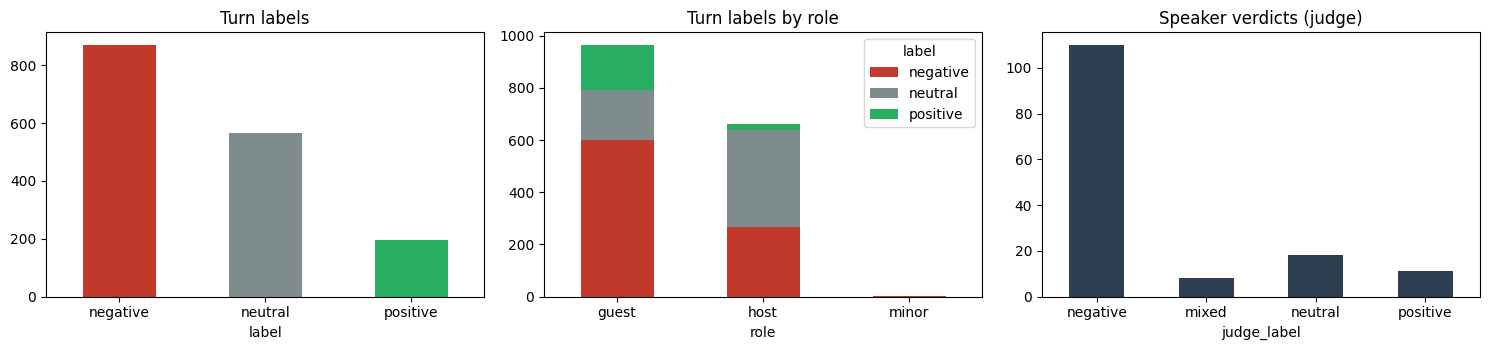

turn labels by role (row %):
label  negative  neutral  positive
role                              
guest      62.4     19.9      17.7
host       40.1     56.4       3.5
minor     100.0      0.0       0.0


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))

turns_df.label.value_counts().reindex(TURN_CLASSES).plot(
    kind="bar", ax=axes[0], color=["#c0392b", "#7f8c8d", "#27ae60"])
axes[0].set_title("Turn labels"); axes[0].tick_params(axis="x", rotation=0)

pd.crosstab(turns_df.role, turns_df.label).reindex(columns=TURN_CLASSES).plot(
    kind="bar", stacked=True, ax=axes[1], color=["#c0392b", "#7f8c8d", "#27ae60"])
axes[1].set_title("Turn labels by role"); axes[1].tick_params(axis="x", rotation=0)

spk_df.judge_label.value_counts().reindex(SPEAKER_CLASSES).fillna(0).plot(
    kind="bar", ax=axes[2], color="#2c3e50")
axes[2].set_title("Speaker verdicts (judge)"); axes[2].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

print("turn labels by role (row %):")
print((pd.crosstab(turns_df.role, turns_df.label, normalize="index") * 100).round(1))


In [8]:
# Three numbers that decide how much to trust what follows.
print(f"mean judge->judge turn agreement : {turns_df.pass_agreement.mean():.3f}"
      f"   (1.000 means the judge was run with --passes 1; re-run with --passes 3"
      f" to get a real self-consistency number)")
print(f"mean training sample weight      : {turns_df.weight.mean():.3f}")
print(f"turns the judge was unsure about : "
      f"{(turns_df.judge_confidence == 'low').mean():.1%}")
print()
print("judge confidence x ASR confidence (low ASR confidence should track low judge confidence):")
print(turns_df.groupby("judge_confidence").asr_confidence.agg(["mean", "count"]).round(4))


mean judge->judge turn agreement : 1.000   (1.000 means the judge was run with --passes 1; re-run with --passes 3 to get a real self-consistency number)
mean training sample weight      : 0.684
turns the judge was unsure about : 21.2%

judge confidence x ASR confidence (low ASR confidence should track low judge confidence):
                    mean  count
judge_confidence               
high             -0.0420    260
low              -0.0449    346
medium           -0.0455   1024


### A caution that belongs in the write-up

Every label below is produced by an LLM reading noisy ASR output. Two consequences:

1. **The ceiling is the judge, not the truth.** A test macro-F1 of 0.80 means the student model
   reproduces the judge 80% of the time — it does not mean 80% of speakers are correctly
   characterised. To claim the latter you need human labels on a held-out sample.
2. **Judge errors are systematic, not random.** If the judge over-reads negativity in garbled
   text, the fine-tuned model will learn to do the same, and no amount of held-out evaluation
   against judge labels will reveal it.

Section 11 sets up the human-verification sample that closes this gap. Budget for it before
reporting a headline number.


## 4. Text preparation and input construction


In [9]:
try:
    from normalizer import normalize as bn_normalize
    HAVE_NORMALIZER = True
except ImportError:
    HAVE_NORMALIZER = False
    print("csebuetnlp normalizer not installed - falling back to NFC only. "
          "Install it: pip install git+https://github.com/csebuetnlp/normalizer")
    import unicodedata
    def bn_normalize(t, **kw):
        return unicodedata.normalize("NFC", t)

def clean(text: str) -> str:
    """BanglaBERT's pretraining pipeline: unicode normalisation, punctuation
    normalisation, whitespace collapse. This ASR emits no punctuation, so the
    main effect here is the Bengali unicode normalisation."""
    return re.sub(r"\s+", " ", bn_normalize(str(text))).strip()

ROLE_TOKEN = {"host": "সঞ্চালক", "guest": "অতিথি", "minor": "অন্য", "unassigned": "অজানা"}

def build_input(row, prev_text=None, mode=CFG.input_mode):
    """Four ways to present one turn to the encoder. They are a real ablation,
    not a stylistic choice - run section 10 to see which wins on your data.

      plain        : the turn alone. The baseline.
      role_turn    : sentence pair (role, turn). Lets the model learn that a
                     host asking a pointed question is not asserting a stance -
                     the single biggest confusion in this corpus.
      context      : sentence pair (previous turn, this turn). Supplies the
                     question a guest is answering, which often carries the
                     subject the stance attaches to.
      role_context : role and previous turn packed into segment A.
    """
    text = clean(row["text"])
    role = ROLE_TOKEN.get(row.get("role", "unassigned"), "অজানা")
    if mode == "plain":
        return text, None
    if mode == "role_turn":
        return role, text
    if mode == "context":
        return clean(prev_text) if prev_text else role, text
    if mode == "role_context":
        head = role if not prev_text else f"{role} {clean(prev_text)}"
        return head, text
    raise ValueError(mode)

# Previous turn within the same episode, for the context modes.
turns_df = turns_df.sort_values(["global_episode", "turn_index"]).reset_index(drop=True)
turns_df["prev_text"] = (turns_df.groupby("global_episode")["text"]
                         .shift(1).fillna(""))
print(turns_df.loc[2, ["role", "label", "n_words"]].to_dict())
print("A:", build_input(turns_df.loc[2], turns_df.loc[2, "prev_text"])[0][:120])
print("B:", build_input(turns_df.loc[2], turns_df.loc[2, "prev_text"])[1][:200])


{'role': 'guest', 'label': 'negative', 'n_words': 714}
A: অতিথি
B: ওনারা দুই লক্ষ কোটি টাকার এডিপি নির্ধারণ করেছিলেন এবং কাজ করেছেন এক লক্ষ কোটি টাকা এবং এটাকে আমি একটা স্বস্তির কারণ বলি আমি বাংলাদেশে কিন্তু বেশি কাজকে আমি একটু এক্সেপশনাল অবস্থান এখেনেন তিনি বড় এডিপ


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/528k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

  p50      78 subword tokens
  p75     196 subword tokens
  p90     379 subword tokens
  p95     560 subword tokens
  p99     824 subword tokens
  max     929

turns that would be truncated at max_len=256: 19.2%


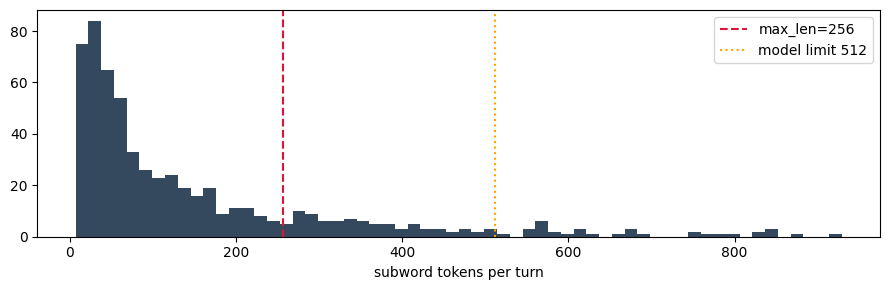

In [10]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(CFG.model_name)

lengths = [len(tokenizer(clean(t), add_special_tokens=True)["input_ids"])
           for t in turns_df.text.sample(min(600, len(turns_df)), random_state=0)]
lengths = np.array(lengths)
for q in (50, 75, 90, 95, 99):
    print(f"  p{q:<3d} {np.percentile(lengths, q):6.0f} subword tokens")
print(f"  max  {lengths.max():6d}")
print(f"\nturns that would be truncated at max_len={CFG.max_len}: "
      f"{(lengths > CFG.max_len).mean():.1%}")

plt.figure(figsize=(9, 3))
plt.hist(lengths, bins=60, color="#34495e")
plt.axvline(CFG.max_len, color="crimson", ls="--", label=f"max_len={CFG.max_len}")
plt.axvline(512, color="orange", ls=":", label="model limit 512")
plt.xlabel("subword tokens per turn"); plt.legend(); plt.tight_layout(); plt.show()


**On truncation.** Guest turns in this corpus run long — a single answer can be four minutes of
speech. Three options, in increasing cost:

- `max_len=256` and accept head truncation (the default; stance is usually stated early).
- `max_len=512` — the model's hard limit, roughly 2× the compute.
- **Split long turns into overlapping windows, predict each, and average.** This is what
  section 8 does at the speaker level anyway, so the machinery is already there. Enable it by
  setting `CFG.window_long_turns = True` below if p95 is above your `max_len`.


## 5. Dataset and collator


In [11]:
class TurnDataset(Dataset):
    def __init__(self, df, tokenizer, max_len, mode, labelled=True):
        self.rows = df.reset_index(drop=True)
        self.tok, self.max_len, self.mode = tokenizer, max_len, mode
        self.labelled = labelled

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        row = self.rows.loc[i]
        a, b = build_input(row, row.get("prev_text", ""), self.mode)
        enc = self.tok(a, b, truncation=True, max_length=self.max_len,
                       padding="max_length", return_tensors="pt")
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labelled:
            item["labels"] = torch.tensor(T2I[row["label"]], dtype=torch.long)
            # Judge confidence x pass agreement. A turn the judge hedged on moves
            # the weights less than one it was sure of.
            item["weight"] = torch.tensor(
                float(row["weight"]) if CFG.use_sample_weights else 1.0,
                dtype=torch.float)
        item["row_index"] = torch.tensor(i, dtype=torch.long)
        return item

def make_loader(df, shuffle, batch_size=None):
    ds = TurnDataset(df, tokenizer, CFG.max_len, CFG.input_mode)
    return DataLoader(ds, batch_size=batch_size or CFG.batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=(DEVICE.type == "cuda"))

train_df = turns_df[turns_df.split == "train"].copy()
val_df   = turns_df[turns_df.split == "val"].copy()
test_df  = turns_df[turns_df.split == "test"].copy()

train_loader = make_loader(train_df, True)
val_loader   = make_loader(val_df, False)
test_loader  = make_loader(test_df, False)
print(f"train {len(train_df):5d} | val {len(val_df):5d} | test {len(test_df):5d}")


train  1009 | val   297 | test   324


In [12]:
# Class weights: this corpus is dominated by neutral, and an unweighted model
# reaches a respectable accuracy by never predicting positive at all.
counts = Counter(train_df.label)
print("train class counts:", dict(counts))
if CFG.class_weighting:
    total = sum(counts.values())
    w = torch.tensor([total / (len(TURN_CLASSES) * max(counts[c], 1))
                      for c in TURN_CLASSES], dtype=torch.float, device=DEVICE)
    w = w / w.mean()
else:
    w = torch.ones(len(TURN_CLASSES), device=DEVICE)
print("class weights:", {c: round(float(x), 3) for c, x in zip(TURN_CLASSES, w)})


train class counts: {'negative': 530, 'neutral': 365, 'positive': 114}
class weights: {'negative': 0.422, 'neutral': 0.613, 'positive': 1.964}


## 6. Model


In [13]:
from transformers import AutoConfig, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

def build_model(name=None):
    name = name or CFG.model_name
    cfg = AutoConfig.from_pretrained(
        name, num_labels=len(TURN_CLASSES),
        id2label=I2T, label2id=T2I,
        hidden_dropout_prob=CFG.dropout,
        attention_probs_dropout_prob=CFG.dropout,
    )
    return AutoModelForSequenceClassification.from_pretrained(name, config=cfg).to(DEVICE)

model = build_model()
n_params = sum(p.numel() for p in model.parameters())
print(f"{CFG.model_name}: {n_params/1e6:.1f}M parameters, "
      f"{model.config.num_hidden_layers} layers, hidden {model.config.hidden_size}")


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  443MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  443MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


csebuetnlp/banglabert: 110.6M parameters, 12 layers, hidden 768


In [14]:
def make_optimizer(model):
    """No weight decay on biases and LayerNorm; a faster LR on the randomly
    initialised classifier head than on the pretrained encoder."""
    no_decay = ("bias", "LayerNorm.weight", "layer_norm")
    head_names = ("classifier", "pooler")
    groups = [
        {"params": [p for n, p in model.named_parameters()
                    if not any(h in n for h in head_names) and not any(nd in n for nd in no_decay)],
         "weight_decay": CFG.weight_decay, "lr": CFG.lr},
        {"params": [p for n, p in model.named_parameters()
                    if not any(h in n for h in head_names) and any(nd in n for nd in no_decay)],
         "weight_decay": 0.0, "lr": CFG.lr},
        {"params": [p for n, p in model.named_parameters() if any(h in n for h in head_names)],
         "weight_decay": CFG.weight_decay, "lr": CFG.head_lr},
    ]
    return torch.optim.AdamW(groups)


def weighted_loss(logits, labels, weights=None):
    """Per-sample weighted, class-balanced cross entropy with label smoothing.

    Label smoothing is doing real work here, not decoration: the targets are
    silver labels from an LLM, and a model trained to be certain about them
    inherits the judge's mistakes with full confidence."""
    per_sample = F.cross_entropy(logits, labels, weight=w,
                                 label_smoothing=CFG.label_smoothing,
                                 reduction="none")
    if weights is not None:
        per_sample = per_sample * weights
        return per_sample.sum() / weights.sum().clamp(min=1e-8)
    return per_sample.mean()


## 7. Training and turn-level evaluation


In [15]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    logits_all, labels_all, idx_all = [], [], []
    for batch in loader:
        idx_all.append(batch.pop("row_index"))
        labels = batch.pop("labels", None)
        batch.pop("weight", None)
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(**batch)
        logits_all.append(out.logits.float().cpu())
        if labels is not None:
            labels_all.append(labels)
    logits = torch.cat(logits_all)
    probs = F.softmax(logits, dim=-1).numpy()
    labels = torch.cat(labels_all).numpy() if labels_all else None
    return probs, labels, torch.cat(idx_all).numpy()


def train(model, train_loader, val_loader, epochs=None, verbose=True):
    epochs = epochs or CFG.epochs
    optimizer = make_optimizer(model)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * CFG.warmup_ratio), total_steps)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

    best = {"f1": -1.0, "epoch": -1, "state": None}
    history = []
    for epoch in range(1, epochs + 1):
        # Optional warm-up phase: let the head find a sensible region before the
        # pretrained encoder is disturbed. Helps most when train is small.
        freeze = epoch <= CFG.freeze_epochs
        for n, p in model.named_parameters():
            p.requires_grad = (not freeze) or ("classifier" in n or "pooler" in n)

        model.train()
        running, seen = 0.0, 0
        for batch in train_loader:
            batch.pop("row_index")
            weights = batch.pop("weight").to(DEVICE)
            labels = batch.pop("labels").to(DEVICE)
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                logits = model(**batch).logits
                loss = weighted_loss(logits.float(), labels, weights)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.max_grad_norm)
            scaler.step(optimizer); scaler.update(); scheduler.step()
            running += loss.item() * len(labels); seen += len(labels)

        probs, y, _ = predict(model, val_loader)
        pred = probs.argmax(1)
        macro = f1_score(y, pred, average="macro", zero_division=0)
        history.append({"epoch": epoch, "train_loss": running / seen,
                        "val_macro_f1": macro, "val_acc": accuracy_score(y, pred)})
        if verbose:
            print(f"epoch {epoch}  loss {running/seen:.4f}  "
                  f"val macro-F1 {macro:.4f}  val acc {accuracy_score(y, pred):.4f}"
                  + ("  <- best" if macro > best['f1'] else ""))
        if macro > best["f1"]:
            best = {"f1": macro, "epoch": epoch,
                    "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}

    model.load_state_dict(best["state"])
    if verbose:
        print(f"\nrestored epoch {best['epoch']} (val macro-F1 {best['f1']:.4f})")
    return model, pd.DataFrame(history)


In [16]:
set_seed(CFG.seed)
model = build_model()
t0 = time.time()
model, history = train(model, train_loader, val_loader)
print(f"trained in {time.time()-t0:.0f}s")
CFG.out_dir.mkdir(parents=True, exist_ok=True)
history.to_csv(CFG.out_dir / "history.csv", index=False)
print(f"per-epoch history -> {CFG.out_dir / 'history.csv'}")
history


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


epoch 1  loss 0.7036  val macro-F1 0.4565  val acc 0.6229  <- best
epoch 2  loss 0.6148  val macro-F1 0.6488  val acc 0.6801  <- best
epoch 3  loss 0.4811  val macro-F1 0.6599  val acc 0.7273  <- best
epoch 4  loss 0.4028  val macro-F1 0.7039  val acc 0.7475  <- best
epoch 5  loss 0.3413  val macro-F1 0.6777  val acc 0.7340
epoch 6  loss 0.3168  val macro-F1 0.6762  val acc 0.7239

restored epoch 4 (val macro-F1 0.7039)
trained in 125s
per-epoch history -> /content/drive/MyDrive/speaker_sentiment/runs/banglabert_turn/history.csv


,epoch,train_loss,val_macro_f1,val_acc
0,1,0.703618,0.456473,0.622896
1,2,0.614763,0.648804,0.680135
2,3,0.481126,0.659873,0.727273
3,4,0.402770,0.703927,0.747475
4,5,0.341291,0.677697,0.734007
5,6,0.316791,0.676217,0.723906


In [17]:
def report(model, loader, df, title):
    probs, y, idx = predict(model, loader)
    pred = probs.argmax(1)
    macro = f1_score(y, pred, average="macro", zero_division=0)
    print(f"=== {title} ===")
    print(f"macro-F1 {macro:.4f}   accuracy {accuracy_score(y, pred):.4f}   "
          f"kappa {cohen_kappa_score(y, pred):.4f}   n={len(y)}")
    print(classification_report(y, pred, target_names=TURN_CLASSES,
                                digits=3, zero_division=0))
    cm = confusion_matrix(y, pred, labels=range(len(TURN_CLASSES)))
    print(pd.DataFrame(cm, index=[f"true_{c}" for c in TURN_CLASSES],
                       columns=[f"pred_{c}" for c in TURN_CLASSES]))
    out = df.reset_index(drop=True).iloc[idx].copy()
    out["pred"] = [I2T[p] for p in pred]
    for i, c in enumerate(TURN_CLASSES):
        out[f"p_{c}"] = probs[:, i]
    return out, macro

val_pred,  val_f1  = report(model, val_loader,  val_df,  "VALIDATION (turn level)")
print()
test_pred, test_f1 = report(model, test_loader, test_df, "TEST (turn level)")


=== VALIDATION (turn level) ===
macro-F1 0.7039   accuracy 0.7475   kappa 0.5678   n=297
              precision    recall  f1-score   support

    negative      0.804     0.809     0.806       162
     neutral      0.725     0.710     0.717        93
    positive      0.581     0.595     0.588        42

    accuracy                          0.747       297
   macro avg      0.703     0.705     0.704       297
weighted avg      0.748     0.747     0.748       297

               pred_negative  pred_neutral  pred_positive
true_negative            131            21             10
true_neutral              19            66              8
true_positive             13             4             25

=== TEST (turn level) ===
macro-F1 0.6696   accuracy 0.7006   kappa 0.4960   n=324
              precision    recall  f1-score   support

    negative      0.790     0.697     0.740       178
     neutral      0.655     0.722     0.687       108
    positive      0.521     0.658     0.581        

In [18]:
# A majority-class baseline is the number that makes the result meaningful.
maj = Counter(train_df.label).most_common(1)[0][0]
base_f1 = f1_score([T2I[c] for c in test_df.label],
                   [T2I[maj]] * len(test_df), average="macro", zero_division=0)
print(f"majority-class ('{maj}') test macro-F1 : {base_f1:.4f}")
print(f"BanglaBERT             test macro-F1 : {test_f1:.4f}")
print(f"lift                                 : {test_f1 - base_f1:+.4f}")


majority-class ('negative') test macro-F1 : 0.2364
BanglaBERT             test macro-F1 : 0.6696
lift                                 : +0.4333


## 8. From turns to speakers

This is where the notebook answers the question it was built for. The model predicts per turn;
a speaker verdict is an aggregation over that speaker's turns. Five aggregation rules are
scored below against the judge's holistic verdict — the same five that `make_datasets.py`
scored against the *gold* turn labels, so you can see how much accuracy is lost by going
through a predicted intermediate rather than the judge's own turn labels.

**The rule is a hyperparameter, so it is chosen on train+val and reported on test.** Picking the
best of five rules on the test units and then quoting that rule's test score is selection on the
test set; with only ~13 test speakers, the gap between the two is large enough to change the
conclusion. Both numbers are printed below so you can see it for yourself.


In [19]:
CONF_W = {"high": 1.0, "medium": 0.7, "low": 0.4}

def speaker_scores(pred_df, prob_weighted=True):
    """Aggregate turn predictions into one continuous stance score per speaker.

    prob_weighted=True uses the model's P(pos) - P(neg) rather than the hard
    argmax. That keeps the information in a turn the model called neutral at
    0.45/0.40/0.15, which a hard vote throws away - and with only ~15 turns per
    speaker, throwing it away is expensive."""
    rows = []
    for key, grp in pred_df.groupby("speaker_key"):
        if prob_weighted:
            pos, neg = grp.p_positive.values, grp.p_negative.values
        else:
            pos = (grp.pred == "positive").astype(float).values
            neg = (grp.pred == "negative").astype(float).values
        words = grp.n_words.values.astype(float)
        out = {"speaker_key": key, "n_turns": len(grp)}
        out["unweighted"]   = _net(pos, neg, np.ones_like(words))
        out["word_weighted"] = _net(pos, neg, words)
        out["dur_weighted"]  = _net(pos, neg, (grp.end_sec - grp.start_sec).values)
        out["top_k"]         = _net(*_topk(pos, neg, k=5))
        out["hard_vote"]     = _net((grp.pred == "positive").astype(float).values,
                                    (grp.pred == "negative").astype(float).values,
                                    np.ones_like(words))
        out["polar_share"] = float(((grp.pred != "neutral").mean()))
        rows.append(out)
    return pd.DataFrame(rows)

def _net(pos, neg, weights):
    p, n = float((pos * weights).sum()), float((neg * weights).sum())
    return (p - n) / (p + n) if (p + n) > 0 else 0.0

def _topk(pos, neg, k=5):
    """Only the k most opinionated turns vote. A speaker's stance is carried by
    their strongest claims; twenty procedural turns should not dilute them."""
    strength = np.abs(pos - neg)
    idx = np.argsort(-strength)[:k]
    return pos[idx], neg[idx], np.ones(len(idx))

def to_speaker_label(score, polar_share, polar_floor=0.15, mixed_band=0.34):
    if polar_share < polar_floor:
        return "neutral"
    if abs(score) < mixed_band:
        return "mixed"
    return "positive" if score > 0 else "negative"


In [20]:
# Aggregation needs predictions on every split, not just the evaluation ones.
# Train-split turns are in-sample for the encoder, so they are used only to CHOOSE
# the aggregation rule, never to report it - see the selection/report split below.
train_pred, _ = report(model, make_loader(train_df, False), train_df,
                       "TRAIN (turn level, in-sample - for rule selection only)")

all_pred = pd.concat([train_pred.assign(split="train"),
                      val_pred.assign(split="val"),
                      test_pred.assign(split="test")])
scores = speaker_scores(all_pred)

# Only units with a trustworthy speaker id carry a meaningful verdict. Turns from
# fallback-diarized episodes trained the model; they cannot evaluate it here.
valid_spk = spk_df[spk_df.get("speaker_level_valid", True)]
truth = valid_spk.set_index("speaker_key")[["judge_label", "judge_stance_score",
                                            "role", "split", "n_turns"]]
merged = scores.set_index("speaker_key").join(truth, rsuffix="_true", how="inner")

sel_units = merged[merged.split.isin(["train", "val"])]   # choose the rule here
test_units = merged[merged.split == "test"]               # report it here
print(f"{len(merged)} evaluable speaker units "
      f"({len(sel_units)} for selection, {len(test_units)} for reporting) "
      f"of {len(scores)} predicted")

rules = ["unweighted", "word_weighted", "dur_weighted", "top_k", "hard_vote"]

def score_rule(units, rule):
    """All four numbers for one rule on one set of speaker units."""
    pred_labels = [to_speaker_label(s, p)
                   for s, p in zip(units[rule], units.polar_share)]
    # Direction-only: does the model agree on whether this speaker is net
    # unfavourable, net favourable, or neither? For a downstream index of
    # panel sentiment this matters more than telling mixed from neutral.
    to3 = lambda x: "neg" if x == "negative" else "pos" if x == "positive" else "neu"
    corr = (np.corrcoef(units[rule], units.judge_stance_score)[0, 1]
            if len(units) > 2 and units[rule].std() > 0 else float("nan"))
    return {"rule": rule,
            "exact_acc": accuracy_score(units.judge_label, pred_labels),
            "direction_acc": accuracy_score([to3(x) for x in units.judge_label],
                                            [to3(x) for x in pred_labels]),
            "stance_corr": corr,
            "macro_f1": f1_score(units.judge_label, pred_labels,
                                 average="macro", zero_division=0)}

sel_df = pd.DataFrame([score_rule(sel_units, r) for r in rules]).sort_values(
    "macro_f1", ascending=False)
best_rule = sel_df.iloc[0]["rule"]

res_df = pd.DataFrame([score_rule(test_units, r) for r in rules]).sort_values(
    "macro_f1", ascending=False)

print(f"\nrule selection on train+val (n={len(sel_units)}) - best: {best_rule}")
display(sel_df.round(3))
print(f"\nall rules on test (n={len(test_units)}), for transparency. The honest number "
      f"is the '{best_rule}' row, not the top one:")
res_df.round(3)

=== TRAIN (turn level, in-sample - for rule selection only) ===
macro-F1 0.9200   accuracy 0.9316   kappa 0.8843   n=1009
              precision    recall  f1-score   support

    negative      0.966     0.923     0.944       530
     neutral      0.934     0.926     0.930       365
    positive      0.801     0.991     0.886       114

    accuracy                          0.932      1009
   macro avg      0.901     0.947     0.920      1009
weighted avg      0.936     0.932     0.932      1009

               pred_negative  pred_neutral  pred_positive
true_negative            489            23             18
true_neutral              17           338             10
true_positive              0             1            113
147 evaluable speaker units (117 for selection, 30 for reporting) of 147 predicted

rule selection on train+val (n=117) - best: hard_vote


,rule,exact_acc,direction_acc,stance_corr,macro_f1
4,hard_vote,0.752,0.795,0.763,0.613
2,dur_weighted,0.658,0.718,0.832,0.581
1,word_weighted,0.667,0.718,0.839,0.575
3,top_k,0.675,0.718,0.733,0.573
0,unweighted,0.641,0.709,0.869,0.570



all rules on test (n=30), for transparency. The honest number is the 'hard_vote' row, not the top one:


,rule,exact_acc,direction_acc,stance_corr,macro_f1
3,top_k,0.800,0.800,0.628,0.667
4,hard_vote,0.867,0.867,0.451,0.567
2,dur_weighted,0.767,0.800,0.567,0.480
1,word_weighted,0.767,0.800,0.569,0.480
0,unweighted,0.633,0.667,0.691,0.447


aggregation rule: hard_vote  (selected on train+val)
TEST speaker-level, n=30: macro-F1 0.567  exact 0.867  direction 0.867  stance r 0.451
(the rule that happens to win ON test is 'top_k' at macro-F1 0.667 - quoting that would be selection on the test set)

              precision    recall  f1-score   support

    negative      0.957     0.917     0.936        24
       mixed      0.500     1.000     0.667         3
     neutral      1.000     0.500     0.667         2
    positive      0.000     0.000     0.000         1

    accuracy                          0.867        30
   macro avg      0.614     0.604     0.567        30
weighted avg      0.882     0.867     0.860        30

pred_label   negative  mixed  neutral  positive
judge_label                                    
negative           22      2        0         0
mixed               0      3        0         0
neutral             1      0        1         0
positive            0      1        0         0

With 30 test spea

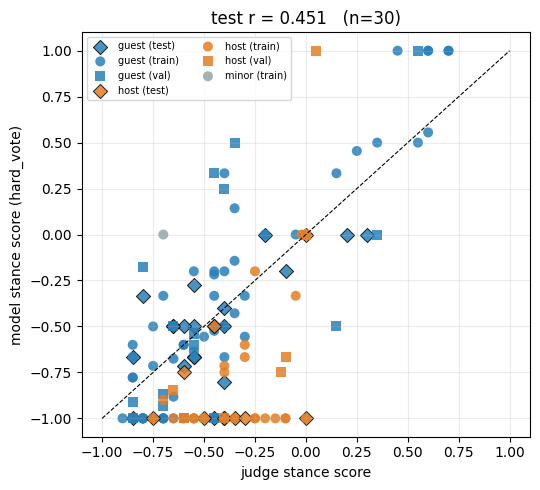

In [21]:
# best_rule was chosen on train+val in the cell above. Report it on test.
merged["pred_label"] = [to_speaker_label(s, p)
                        for s, p in zip(merged[best_rule], merged.polar_share)]
test_units = merged[merged.split == "test"]

chosen = res_df.set_index("rule").loc[best_rule]
print(f"aggregation rule: {best_rule}  (selected on train+val)")
print(f"TEST speaker-level, n={len(test_units)}: "
      f"macro-F1 {chosen.macro_f1:.3f}  exact {chosen.exact_acc:.3f}  "
      f"direction {chosen.direction_acc:.3f}  stance r {chosen.stance_corr:.3f}")
best_on_test = res_df.iloc[0]
if best_on_test["rule"] != best_rule:
    print(f"(the rule that happens to win ON test is '{best_on_test['rule']}' at "
          f"macro-F1 {best_on_test.macro_f1:.3f} - quoting that would be "
          f"selection on the test set)")
print()
print(classification_report(test_units.judge_label, test_units.pred_label,
                            labels=SPEAKER_CLASSES, digits=3, zero_division=0))
print(pd.crosstab(test_units.judge_label, test_units.pred_label).reindex(
    index=SPEAKER_CLASSES, columns=SPEAKER_CLASSES, fill_value=0))
print(f"\nWith {len(test_units)} test speakers over 4 classes, one unit moves macro-F1 by "
      f"roughly {1/len(test_units):.2f}. Treat this as a direction, not a measurement, and "
      f"use section 9's GroupKFold over all valid units for anything you report.")

plt.figure(figsize=(5.5, 5))
colors = {"host": "#e67e22", "guest": "#2980b9", "minor": "#95a5a6", "unassigned": "#bdc3c7"}
markers = {"train": "o", "val": "s", "test": "D"}
for (role, split), grp in merged.groupby(["role", "split"]):
    plt.scatter(grp.judge_stance_score, grp[best_rule], s=52, alpha=0.85,
                label=f"{role} ({split})", color=colors.get(role, "#7f8c8d"),
                marker=markers.get(split, "o"),
                edgecolors="k" if split == "test" else "none", linewidths=0.7)
plt.plot([-1, 1], [-1, 1], "k--", lw=0.8)
plt.xlabel("judge stance score"); plt.ylabel(f"model stance score ({best_rule})")
r_test = np.corrcoef(test_units[best_rule], test_units.judge_stance_score)[0, 1]
plt.title(f"test r = {r_test:.3f}   (n={len(test_units)})")
plt.legend(fontsize=7, ncol=2); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()

### Where it goes wrong


In [22]:
wrong = test_units[test_units.pred_label != test_units.judge_label].copy()
print(f"{len(wrong)} of {len(test_units)} test speakers misclassified\n")
cols = ["role", "split", "n_turns", "judge_label", "pred_label",
        "judge_stance_score", best_rule, "polar_share"]
display(wrong[cols].round(3))

# Read the actual turns behind one disagreement. Do this before changing
# anything: a good share of these will be judge errors, not model errors.
if len(wrong):
    key = wrong.index[0]
    print(f"\n=== {key} : judge={wrong.loc[key,'judge_label']} "
          f"model={wrong.loc[key,'pred_label']} ===")
    print(spk_df.set_index('speaker_key').loc[key, 'summary'])
    print()
    sub = all_pred[all_pred.speaker_key == key].sort_values("turn_index")
    for _, r in sub.head(8).iterrows():
        print(f"[{r.label:8s} -> {r.pred:8s}]  {r.text[:150]}")

4 of 30 test speakers misclassified



,role,split,n_turns,judge_label,pred_label,judge_stance_score,hard_vote,polar_share
speaker_key,,,,,,,,
2107004::ep007::S0,host,test,13,neutral,negative,0.00,-1.000,0.154
2107006::ep009::S2,guest,test,12,negative,mixed,-0.55,-0.273,0.917
2107009::ep005::S1,guest,test,7,negative,mixed,-0.80,-0.333,0.857
2107015::ep008::S2,guest,test,17,positive,mixed,0.30,0.000,0.824



=== 2107004::ep007::S0 : judge=neutral model=negative ===
Kazi Saeed, host of GTV's weekly Business A to Z, running a two-topic episode on the insurance sector and the gas and power crisis with the MD of Pragati Life Insurance and a CNG Owners Association member. He opens by asserting the fuel crisis has taken an acute form, then spends the rest of the episode eliciting: why insurance is neglected, what IDRA can do, why load shedding suddenly rose, whether renewables are affordable, and where a customer denied a claim can turn.

[negative -> neutral ]  দর্শক প্রগতি লাইফ ইন্স্যুরেন্স পিletter of credit এবং পাইনিওর ইন্স্যুরেন্স পিএলসির সৌজন্যে ব্যবসা বাণিজ্য বিষয়ক জিটিভির সাপ্তাহিক আয়াজন বিজনেস এ টু 
[neutral  -> neutral ]  সেটি একটু সংস্কার করে আবার বলতে চাই আপনি যেটি বলেছেন কেন আমি যদি এককথায় জানতে চাই কেন এরকম অবহেলার মধ্যে আছে এবং আইডিয়ার আসলে কোন ভূমিকা রাখতে পারে 
[neutral  -> neutral ]  দেওয়া হয় জনাব জালাল লাজিম আবারও আপনার কাছে আসব আমাদের অনেক কিছু জানার আছে আপনার কাছে আমর

## 9. Optional: a genuinely hierarchical speaker model


Section 8 aggregates with a fixed rule. The alternative is to let the model learn the
aggregation: encode each turn, then pool a speaker's turn vectors with attention and classify
the speaker directly. This is the standard architecture in the emotion-recognition-in-
conversation literature (hierarchical transformers, speaker-aware pooling).

With 147 speaker units it will still overfit if trained from scratch, so it is trained on top of
the **frozen** turn encoder from section 7 — only the pooling and classifier are learned, which is
a few thousand parameters.

**Why grouped CV is still the number to quote.** The held-out speaker split now carries 30 test
units across all four classes, which is a usable sanity check but not a stable measurement: one
unit moves macro-F1 by roughly 0.03, and `positive` and `mixed` number only 11 and 8 units in the
entire corpus. The `GroupKFold` below, over all 147 valid units grouped by episode, uses every
labelled speaker exactly once as test data and is the speaker-level figure that belongs in the
report.


In [ ]:
class AttentionPool(nn.Module):
    """One scalar score per turn, softmaxed into pooling weights. The learned
    weights are readable afterwards: they say which turns the model thought
    defined the speaker."""
    def __init__(self, dim, hidden=128):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(dim, hidden), nn.Tanh(), nn.Linear(hidden, 1))

    def forward(self, x, mask):
        a = self.score(x).squeeze(-1).masked_fill(~mask, float("-inf"))
        a = torch.softmax(a, dim=-1)
        return torch.bmm(a.unsqueeze(1), x).squeeze(1), a


class SpeakerHead(nn.Module):
    def __init__(self, dim, n_classes=len(SPEAKER_CLASSES)):
        super().__init__()
        self.pool = AttentionPool(dim)
        self.cls = nn.Sequential(nn.Dropout(0.2), nn.Linear(dim, 128),
                                 nn.GELU(), nn.Dropout(0.2), nn.Linear(128, n_classes))

    def forward(self, turn_vecs, mask):
        pooled, attn = self.pool(turn_vecs, mask)
        return self.cls(pooled), attn


@torch.no_grad()
def embed_turns(model, df, batch_size=32):
    """[CLS] representation from the fine-tuned encoder, one vector per turn."""
    model.eval()
    base = getattr(model, "electra", None) or getattr(model, "bert", None) \
        or getattr(model, "roberta", None) or model.base_model
    ds = TurnDataset(df, tokenizer, CFG.max_len, CFG.input_mode)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    vecs = []
    for batch in loader:
        batch.pop("row_index"); batch.pop("labels", None); batch.pop("weight", None)
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        vecs.append(base(**batch).last_hidden_state[:, 0].float().cpu())
    return torch.cat(vecs).numpy()

turn_vecs = embed_turns(model, turns_df)
print("turn embeddings:", turn_vecs.shape)


In [ ]:
from sklearn.model_selection import GroupKFold

MAX_TURNS = 40
def pack_speakers(df, vecs, labels_by_key):
    keys, X, M, y, groups = [], [], [], [], []
    for key, grp in df.groupby("speaker_key"):
        if key not in labels_by_key:
            continue
        idx = grp.sort_values("turn_index").index.values[:MAX_TURNS]
        v = vecs[idx]
        pad = MAX_TURNS - len(v)
        X.append(np.vstack([v, np.zeros((pad, v.shape[1]), dtype=v.dtype)]))
        M.append(np.array([True] * len(v) + [False] * pad))
        y.append(SPEAKER_CLASSES.index(labels_by_key[key]))
        groups.append(grp.global_episode.iloc[0]); keys.append(key)
    return (np.stack(X), np.stack(M), np.array(y), np.array(groups), keys)

labels_by_key = dict(zip(valid_spk.speaker_key, valid_spk.judge_label))
X, M, y, groups, keys = pack_speakers(turns_df.reset_index(drop=True), turn_vecs, labels_by_key)
print(f"{len(y)} speaker units, {X.shape[1]} turns x {X.shape[2]} dims, "
      f"{len(set(groups))} episodes")
print("classes:", {SPEAKER_CLASSES[i]: int(n) for i, n in zip(*np.unique(y, return_counts=True))})


In [ ]:
def run_speaker_cv(X, M, y, groups, n_splits=5, epochs=60, lr=1e-3, seed=CFG.seed):
    """Grouped CV, because 61 units is far too few for a single held-out split
    to mean anything - one unlucky episode moves the score by ten points."""
    gkf = GroupKFold(n_splits=n_splits)
    oof = np.zeros(len(y), dtype=int)
    cw = torch.tensor(len(y) / (len(SPEAKER_CLASSES) * np.bincount(y, minlength=len(SPEAKER_CLASSES)).clip(1)),
                      dtype=torch.float, device=DEVICE)
    for fold, (tr, te) in enumerate(gkf.split(X, y, groups), 1):
        set_seed(seed + fold)
        head = SpeakerHead(X.shape[2]).to(DEVICE)
        opt = torch.optim.AdamW(head.parameters(), lr=lr, weight_decay=1e-2)
        Xtr = torch.tensor(X[tr], dtype=torch.float, device=DEVICE)
        Mtr = torch.tensor(M[tr], device=DEVICE)
        ytr = torch.tensor(y[tr], device=DEVICE)
        for _ in range(epochs):
            head.train(); opt.zero_grad()
            logits, _ = head(Xtr, Mtr)
            F.cross_entropy(logits, ytr, weight=cw, label_smoothing=0.1).backward()
            opt.step()
        head.eval()
        with torch.no_grad():
            logits, _ = head(torch.tensor(X[te], dtype=torch.float, device=DEVICE),
                             torch.tensor(M[te], device=DEVICE))
        oof[te] = logits.argmax(1).cpu().numpy()
        print(f"  fold {fold}: n_test={len(te)}  acc={accuracy_score(y[te], oof[te]):.3f}")
    return oof

oof = run_speaker_cv(X, M, y, groups)
print(f"\nhierarchical speaker model, out-of-fold over all {len(y)} units:")
print(f"  accuracy {accuracy_score(y, oof):.3f}   "
      f"macro-F1 {f1_score(y, oof, average='macro', zero_division=0):.3f}")
print(classification_report(y, oof, target_names=SPEAKER_CLASSES, digits=3, zero_division=0))
print("\nCompare against the fixed-rule aggregation in section 8. If the fixed rule wins, "
      "say so and use it: with this much data, a learned pooling layer usually does not "
      "earn its extra variance.")


## 10. Optional: ablations — which backbone, which input format


Both questions are cheap to answer and neither should be assumed. BanglaBERT is the strongest
Bangla-specific encoder on published benchmarks, but this is ASR text from a narrow domain, and
multilingual models sometimes handle the code-mixed English financial vocabulary
(*inflation*, *reserve*, *budget*) better than a Bangla-only tokenizer does.

**To run it, set `RUN_ABLATION = True` in the next cell.** Each configuration costs roughly one
section-7 training run at 4 epochs. On a Colab T4 the full 4 x 3 sweep takes about 25 minutes; on
CPU it is closer to eight hours, so trim `BACKBONES` or leave the flag off. Results are written to
`runs/.../presentation/ablation.csv` and plotted, so the comparison ends up in a file rather than
only in the cell output.


In [ ]:
BACKBONES = [
    "csebuetnlp/banglabert",       # ELECTRA discriminator, Bangla-only, 110M — the default
    "csebuetnlp/banglishbert",     # Bangla + English pretraining; better on code-mixed terms
    "xlm-roberta-base",            # multilingual baseline, 270M
    "google/muril-base-cased",     # 17 Indian languages incl. Bangla, transliteration-aware
    # "sagorsarker/bangla-bert-base",  # older Bangla BERT; include for a historical comparison
]
INPUT_MODES = ["plain", "role_turn", "context"]

def evaluate_config(model_name, input_mode, epochs=4, seed=CFG.seed):
    global tokenizer
    prev_tok, prev_mode = tokenizer, CFG.input_mode
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    CFG.input_mode = input_mode
    try:
        set_seed(seed)
        m = build_model(model_name)
        m, _ = train(m, make_loader(train_df, True), make_loader(val_df, False),
                     epochs=epochs, verbose=False)
        vp, vy, _ = predict(m, make_loader(val_df, False))
        tp, ty, ti = predict(m, make_loader(test_df, False))
        out = test_df.reset_index(drop=True).iloc[ti].copy()
        out["pred"] = [I2T[p] for p in tp.argmax(1)]
        for i, c in enumerate(TURN_CLASSES):
            out[f"p_{c}"] = tp[:, i]
        row = {
            "model": model_name.split("/")[-1], "input": input_mode,
            "val_f1": f1_score(vy, vp.argmax(1), average="macro", zero_division=0),
            "test_f1": f1_score(ty, tp.argmax(1), average="macro", zero_division=0),
            "test_acc": accuracy_score(ty, tp.argmax(1)),
        }
        del m; torch.cuda.empty_cache()
        return row, out
    finally:
        tokenizer, CFG.input_mode = prev_tok, prev_mode

# --- the sweep ----------------------------------------------------------------
# Set to True to run. Selection is on VAL; TEST is reported but never used to choose.
RUN_ABLATION = False          # <-- flip this on a GPU runtime
ABLATION_BACKBONES = BACKBONES            # trim this list to shorten the sweep
ABLATION_MODES = INPUT_MODES
ABLATION_EPOCHS = 4

if RUN_ABLATION:
    import time as _time
    PRES = CFG.out_dir / "presentation"; PRES.mkdir(parents=True, exist_ok=True)
    ablation, preds = [], {}
    total = len(ABLATION_BACKBONES) * len(ABLATION_MODES)
    t_start = _time.time()
    for k, name in enumerate(ABLATION_BACKBONES):
        for mode in ABLATION_MODES:
            n_done = len(ablation)
            try:
                r, p = evaluate_config(name, mode, epochs=ABLATION_EPOCHS)
            except Exception as exc:                 # a backbone may fail to download
                print(f"  SKIPPED {name} / {mode}: {type(exc).__name__}: {exc}")
                continue
            ablation.append(r); preds[(r["model"], mode)] = p
            el = _time.time() - t_start
            print(f"[{n_done+1}/{total}] {r['model']:18s} {mode:12s} "
                  f"val {r['val_f1']:.4f}  test {r['test_f1']:.4f}  "
                  f"({el/60:.1f} min elapsed)")

    abl = pd.DataFrame(ablation).sort_values("val_f1", ascending=False).round(4)
    abl.to_csv(PRES / "ablation.csv", index=False)

    # the honest read: pick on val, then report that row's test score
    best = abl.iloc[0]
    print(f"\nselected on VAL: {best['model']} / {best['input']}  "
          f"-> TEST macro-F1 {best['test_f1']:.4f}")
    if abl.test_f1.idxmax() != abl.index[0]:
        w = abl.loc[abl.test_f1.idxmax()]
        print(f"(the config that happens to win ON test is {w['model']} / {w['input']} "
              f"at {w['test_f1']:.4f} - quoting that would be selection on the test set)")

    piv = abl.pivot_table(index="model", columns="input", values="val_f1")
    ax = piv.plot(kind="bar", figsize=(9, 4.2), rot=15)
    ax.set_ylabel("validation macro-F1"); ax.set_xlabel("")
    ax.set_title("Backbone x input format (selected on validation)")
    ax.grid(axis="y", alpha=.3); ax.legend(title="input mode")
    plt.tight_layout(); plt.savefig(PRES / "ablation.png", dpi=160); plt.show()
    display(abl)
else:
    print(f"{len(BACKBONES)} backbones x {len(INPUT_MODES)} input modes = "
          f"{len(BACKBONES)*len(INPUT_MODES)} runs, ~4 epochs each.")
    print("Set RUN_ABLATION = True above to run it (GPU strongly recommended).")
    print("Select on VAL, report on TEST. Picking the backbone by its test score is how "
          "a paper ends up with a number it cannot reproduce.")

## 11. Human verification — the step that makes the numbers claimable


Everything above measures agreement with an LLM judge. To report a defensible accuracy you need
a human-labelled sample. The cell below draws a stratified sample of turns for hand-labelling
and, once you fill in the labels, computes:

- **Judge vs human** — how good the supervision actually is (this bounds everything).
- **Model vs human** — the number to report.
- **Cohen's κ** — with a second annotator, whether the label scheme is even reliable.

180 turns is roughly two hours of work and is enough for a credible confidence interval on a
3-class task. Stratify by predicted label and by ASR confidence so the sample contains the
cases where the judge is most likely to be wrong.


In [ ]:
def draw_gold_sample(pred_df, n=180, seed=CFG.seed):
    rng = np.random.RandomState(seed)
    pool = pred_df.copy()
    pool["conf_band"] = pd.qcut(pool.asr_confidence.fillna(pool.asr_confidence.median()),
                                3, labels=["low", "mid", "high"], duplicates="drop")
    per_cell = max(1, n // (pool.pred.nunique() * pool.conf_band.nunique()))
    picks = []
    for _, grp in pool.groupby(["pred", "conf_band"], observed=True):
        picks.append(grp.sample(min(per_cell, len(grp)), random_state=rng))
    sample = pd.concat(picks).sample(frac=1, random_state=rng).head(n)
    return sample[["turn_id", "speaker_key", "role", "text", "n_words",
                   "asr_confidence", "label", "judge_confidence", "pred"]]

gold = draw_gold_sample(all_pred)
out_path = CFG.data_dir / "gold_sample_to_label.jsonl"
blind = gold.drop(columns=["label", "pred", "judge_confidence"]).copy()
blind["human_label"] = ""   # fill with negative / neutral / positive / illegible
blind["annotator"] = ""
blind.to_json(out_path, orient="records", lines=True, force_ascii=False)
print(f"wrote {len(blind)} turns to {out_path}")
print("Judge and model labels are withheld from this file on purpose: an annotator "
      "who can see the machine label will agree with it.")
gold.pred.value_counts()


In [ ]:
# Run after the file has been filled in.
GOLD_LABELLED = CFG.data_dir / "gold_sample_labelled.jsonl"
if GOLD_LABELLED.exists():
    human = pd.DataFrame(load_jsonl(GOLD_LABELLED))
    human = human[human.human_label.isin(TURN_CLASSES)]
    ev = human.merge(all_pred[["turn_id", "label", "pred"]], on="turn_id")
    print(f"n = {len(ev)}\n")
    print(f"JUDGE vs HUMAN  macro-F1 {f1_score(ev.human_label, ev.label, average='macro', zero_division=0):.3f}"
          f"   kappa {cohen_kappa_score(ev.human_label, ev.label):.3f}")
    print(f"MODEL vs HUMAN  macro-F1 {f1_score(ev.human_label, ev.pred,  average='macro', zero_division=0):.3f}"
          f"   kappa {cohen_kappa_score(ev.human_label, ev.pred):.3f}")
    print("\nModel vs human, per class:")
    print(classification_report(ev.human_label, ev.pred, digits=3, zero_division=0))
    print("\nIf judge-vs-human is well below model-vs-judge, the supervision is the "
          "bottleneck: revise the rubric in llm_judge.py and re-judge, rather than "
          "tuning hyperparameters.")
else:
    print(f"{GOLD_LABELLED} not found - label {out_path.name} first.")


## 12. Save and use


In [ ]:
model.save_pretrained(CFG.out_dir / "model")
tokenizer.save_pretrained(CFG.out_dir / "model")
meta = {
    "backbone": CFG.model_name,
    "input_mode": CFG.input_mode,
    "max_len": CFG.max_len,
    "turn_classes": TURN_CLASSES,
    "speaker_classes": SPEAKER_CLASSES,
    "best_aggregation_rule": best_rule,
    "aggregation_rule_selected_on": "train+val speaker units",
    "speaker_level_selection": sel_df.to_dict("records"),
    "val_turn_macro_f1": float(val_f1),
    "test_turn_macro_f1": float(test_f1),
    "majority_baseline_test_macro_f1": float(base_f1),
    "speaker_level": res_df.to_dict("records"),
    "n_train_turns": int(len(train_df)),
    "label_source": "LLM-as-judge (claude-opus-5), no human labels",
    "caveat": "scores measure agreement with the LLM judge, not with human ground truth",
}
(CFG.out_dir / "metrics.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
test_pred.to_json(CFG.out_dir / "test_predictions.jsonl", orient="records",
                  lines=True, force_ascii=False)
print(json.dumps(meta, indent=2)[:900])
print(f"\nmodel + metrics written to {CFG.out_dir}")
if IN_COLAB and "/content/drive/" in str(CFG.out_dir):
    print("It is on Drive, so it survives this runtime being recycled.")
elif IN_COLAB:
    print("WARNING: this is NOT on Drive. Copy it out before the runtime recycles:")
    print(f"  !cp -r '{CFG.out_dir}' /content/drive/MyDrive/")


### Presentation artefacts

Everything a slide deck needs, written next to the model: per-epoch curves, the test confusion
matrix, per-class scores, accuracy sliced by speaker role and by ASR confidence, and readable
prediction examples. Run this after section 12 so `test_pred` and `history` exist.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

PRES = CFG.out_dir / "presentation"
PRES.mkdir(parents=True, exist_ok=True)

# ---- training curves ----------------------------------------------------
best_ep = int(history.loc[history.val_macro_f1.idxmax(), "epoch"])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history.epoch, history.train_loss, "o-", color="#c0392b")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("training loss")
ax[0].set_title("Training loss"); ax[0].grid(alpha=.3)
ax[1].plot(history.epoch, history.val_macro_f1, "o-", label="val macro-F1", color="#2980b9")
ax[1].plot(history.epoch, history.val_acc, "s--", label="val accuracy", color="#27ae60")
ax[1].axvline(best_ep, color="k", ls=":", lw=1, label=f"best epoch = {best_ep}")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("score")
ax[1].set_title("Validation performance"); ax[1].legend(); ax[1].grid(alpha=.3)
fig.suptitle(f"{CFG.model_name} turn-level fine-tuning")
fig.tight_layout(); fig.savefig(PRES / "training_curves.png", dpi=160); plt.show()

# ---- confusion matrix ---------------------------------------------------
cm = confusion_matrix(test_pred.label, test_pred.pred, labels=TURN_CLASSES)
cmn = cm / cm.sum(1, keepdims=True)
fig, ax = plt.subplots(figsize=(5.6, 5))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(TURN_CLASSES, rotation=20)
ax.set_yticks(range(3)); ax.set_yticklabels(TURN_CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("true (judge label)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i,j]}\n{cmn[i,j]:.0%}", ha="center", va="center",
                color="white" if cmn[i,j] > .5 else "black")
ax.set_title(f"Test confusion matrix (n={len(test_pred)})")
fig.colorbar(im, ax=ax, shrink=.8)
fig.tight_layout(); fig.savefig(PRES / "confusion_matrix.png", dpi=160); plt.show()
pd.DataFrame(cm, index=[f"true_{c}" for c in TURN_CLASSES],
             columns=[f"pred_{c}" for c in TURN_CLASSES]).to_csv(PRES / "confusion_matrix.csv")

# ---- per class, role and transcript quality -----------------------------
rep = classification_report(test_pred.label, test_pred.pred, labels=TURN_CLASSES,
                            output_dict=True, zero_division=0)
pd.DataFrame(rep).T.to_csv(PRES / "per_class_test.csv")

rows = []
for role, g in test_pred.groupby("role"):
    rows.append({"role": role, "n": len(g),
                 "accuracy": accuracy_score(g.label, g.pred),
                 "macro_f1": f1_score(g.label, g.pred, average="macro", zero_division=0)})
pd.DataFrame(rows).to_csv(PRES / "breakdown_role.csv", index=False)

tq = test_pred.copy()
tq["asr_q"] = pd.qcut(pd.to_numeric(tq.asr_confidence, errors="coerce"), 4,
                      labels=["Q1 worst", "Q2", "Q3", "Q4 best"], duplicates="drop")
rows = []
for name, g in tq.groupby("asr_q", observed=True):
    rows.append({"asr_quartile": str(name), "n": len(g),
                 "mean_asr_conf": float(g.asr_confidence.mean()),
                 "accuracy": accuracy_score(g.label, g.pred),
                 "macro_f1": f1_score(g.label, g.pred, average="macro", zero_division=0)})
qual = pd.DataFrame(rows); qual.to_csv(PRES / "breakdown_quality.csv", index=False)

# ---- readable examples --------------------------------------------------
pcols = [f"p_{c}" for c in TURN_CLASSES]
test_pred["_conf"] = test_pred[pcols].max(axis=1)
for name, sel in [("examples_correct.md", test_pred.label == test_pred.pred),
                  ("examples_errors.md",  test_pred.label != test_pred.pred)]:
    g = test_pred[sel].sort_values("_conf", ascending=False).head(12)
    lines = [f"# {name[:-3].replace('_', ' ')}", ""]
    for _, r in g.iterrows():
        lines += [f"**{r.turn_id}** role=`{r.role}` words={r.n_words} "
                  f"asr_conf={r.asr_confidence:.3f}", "",
                  f"- judge: `{r.label}` | model: `{r.pred}` (p={r._conf:.2f})", "",
                  "> " + str(r.text)[:420], "", "---", ""]
    (PRES / name).write_text("\n".join(lines), encoding="utf-8")

print(f"test macro-F1 {f1_score(test_pred.label, test_pred.pred, average='macro'):.4f} | "
      f"kappa {cohen_kappa_score(test_pred.label, test_pred.pred):.4f} | best epoch {best_ep}")
print(qual.to_string(index=False))
print(f"\nwrote {len(list(PRES.iterdir()))} files to {PRES}")

In [ ]:
@torch.no_grad()
def analyse_speaker(turn_texts, role="guest", rule=None):
    """End-to-end inference: a speaker's turns in, a verdict out."""
    rule = rule or best_rule
    model.eval()
    rows = pd.DataFrame({"text": turn_texts, "role": role,
                         "n_words": [len(t.split()) for t in turn_texts]})
    rows["prev_text"] = rows.text.shift(1).fillna("")
    probs = []
    for _, r in rows.iterrows():
        a, b = build_input(r, r.prev_text)
        enc = tokenizer(a, b, truncation=True, max_length=CFG.max_len,
                        padding="max_length", return_tensors="pt").to(DEVICE)
        probs.append(F.softmax(model(**enc).logits.float(), -1)[0].cpu().numpy())
    probs = np.array(probs)
    rows["pred"] = [I2T[i] for i in probs.argmax(1)]
    for i, c in enumerate(TURN_CLASSES):
        rows[f"p_{c}"] = probs[:, i]
    pos, neg = rows.p_positive.values, rows.p_negative.values
    if rule == "word_weighted":
        score = _net(pos, neg, rows.n_words.values.astype(float))
    elif rule == "top_k":
        score = _net(*_topk(pos, neg, k=5))
    elif rule == "hard_vote":
        score = _net((rows.pred == "positive").astype(float).values,
                     (rows.pred == "negative").astype(float).values, np.ones(len(rows)))
    else:                       # unweighted, and dur_weighted without timings
        score = _net(pos, neg, np.ones(len(rows)))
    polar = float((rows.pred != "neutral").mean())
    return {"speaker_label": to_speaker_label(score, polar),
            "stance_score": round(score, 3),
            "polar_share": round(polar, 3),
            "turns": rows[["pred", "p_negative", "p_neutral", "p_positive"]].round(3)}

demo_key = merged.index[0]
demo = all_pred[all_pred.speaker_key == demo_key].sort_values("turn_index")
result = analyse_speaker(demo.text.tolist(), role=demo.role.iloc[0])
print(f"{demo_key}: judge said {merged.loc[demo_key,'judge_label']}, "
      f"model says {result['speaker_label']} ({result['stance_score']:+.3f})")
result["turns"].head(10)


## 13. Where to take this next

Ordered by how much each is likely to move the number, based on what this corpus actually
looks like:

1. **Fix the ASR, not the classifier.** Word error rate was never measured in this project
   (`wer_measured: SKIPPED`, "requires gold transcript"). Every score here is bounded by
   transcript quality. Hand-transcribe 10 minutes per programme, measure WER, and if it is
   above ~40% no modelling change will help much.
2. **Re-diarize `2107009`.** Those five episodes fell back to energy-based segmentation and
   roughly 60% of their words are unassigned, which is why they are excluded here. Recovering
   them adds five episodes — a 25% increase in usable data.
3. **Continue pretraining on in-domain text.** Domain-adaptive pretraining (masked-LM on
   unlabelled Bangla financial news and these transcripts, before fine-tuning) is the
   reliable win for a low-resource domain shift, typically worth several F1 points.
4. **Human-verify the judge** (section 11), then re-judge with a rubric revised from the
   disagreements. Improving supervision beats tuning the student.
5. **Add the audio.** The WAVs are sitting in `results/processed/`. Prosody carries stance
   that a noisy transcript loses; a wav2vec2/WavLM branch fused with the text branch is the
   standard multimodal setup and this dataset is unusually well suited to it.
6. **Speaker × target matrix.** Combine this with the existing target-aware pipeline in
   `sentiment/` to produce, per speaker, a stance per financial target — "this economist is
   negative on banking and positive on remittances" — which is far more useful for a
   downstream financial index than a single speaker label.
